# 08 — Message-Passing Aggregation Sweep (Sweep B)

Staged ablation, Sweep B. Isolates the `MessageLayer` aggregation choice —
`mean`, `sum`, `max`, or `multi` (mean+sum+max concatenated) — for both
`DistanceESPN` and `AttentionESPN`, with query node features held off and
batching at defaults so the comparison isn't confounded by anything else.
`mean`/`sum`/`max` were (re)trained under the current EMA + protein-weighted
baseline as `checkpoints/phase_b`; the `multi` arm reuses `checkpoints/phase_a/*_pw05`
(Sweep A's winner) rather than retraining an identical config.

## Selection methodology

**Winners are chosen from validation metrics (Section 5), not test metrics
(Section 6).** `07_train.py` auto-evaluates every run against the test set on
completion — using those numbers to pick a winner would mean implicitly
fitting the test set. Section 6 is included only as a sanity check.

Primary metric: per-run validation Pearson r, taken from the epoch that
produced `best_model.pt` (i.e. the epoch with minimum val loss, read from
`metrics.csv`). Secondary/tie-break: validation RMSE. Also watch the
train/val gap — a config with slightly lower val Pearson r but a much
smaller train/val gap generalizes better and may be the better pick despite
not topping the leaderboard.

Aggregation for `AttentionESPN` only affects the bond/radial/qq
(`_AtomMP`/`_QueryRefine`) stages — its AQ stage is always cross-attention
regardless of this setting.

In [10]:
import json
import sys
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("../..").resolve()))


def show_png_grid(runs, filename, title, ncols=2):
    """Display saved PNG plots from each run's plot_dir in a grid.

    analyze_model.py saves plots with a model-name prefix (e.g.
    'attention_parity_hexbin.png', 'distance_parity_hexbin.png'), so the
    actual filename is built per-run from run['model_type'] — passing a
    bare 'parity_hexbin.png' here is deliberate, the prefix is added below.
    """
    def _path(run):
        return run["plot_dir"] / f"{run['model_type']}_{filename}"

    available = [r for r in runs if _path(r).exists()]
    if not available:
        print(f"No '*_{filename}' plots found. Run analyze_model.py --save-plots first.")
        return
    nrows = (len(available) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axes = axes.flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    for ax, run in zip(axes, available):
        ax.imshow(mpimg.imread(_path(run)))
        ax.set_title(run["label"], fontsize=11)
        ax.axis("off")
    for ax in axes[len(available):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_metric_bars(df, title_prefix, metrics):
    """1-row x 2-col grouped bar chart: one chart per model type."""
    if df.empty:
        print("No data to plot.")
        return
    model_types = ["Attention", "Distance"]
    fig, axes = plt.subplots(1, len(model_types), figsize=(14, 5), sharey=False)
    fig.suptitle(title_prefix, fontsize=13, fontweight="bold")
    n_metrics = len(metrics)
    total_width = 0.7
    bar_w = total_width / n_metrics
    for ax, model_type in zip(axes, model_types):
        sub = df[df["Model"] == model_type].copy()
        if sub.empty:
            ax.set_visible(False)
            continue
        x = range(len(sub))
        for i, (metric, color) in enumerate(metrics):
            if metric not in sub.columns or sub[metric].isna().all():
                continue
            offsets = [xi - total_width / 2 + bar_w * i + bar_w / 2 for xi in x]
            bars = ax.bar(offsets, sub[metric], width=bar_w, color=color, label=metric, zorder=3)
            ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8, rotation=90)
        ax.set_title(model_type, fontsize=12)
        ax.set_xlabel("Aggregation")
        ax.set_xticks(list(x))
        ax.set_xticklabels(sub["Aggregation"].tolist(), fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(axis="y", alpha=0.3, zorder=0)
    plt.tight_layout()
    plt.show()

## 1. Configuration

In [11]:
THESIS_ROOT = Path("/home/student/thesis")
CKPT_ROOT   = THESIS_ROOT / "checkpoints"
EVAL_ROOT   = THESIS_ROOT / "model_eval"

AGGS = ["mean", "sum", "max", "multi"]

def _agg_run(model, agg):
    if agg == "multi":
        # multi is the current config default — reuse the Sweep A baseline
        # (phase_a/pw05) instead of retraining an identical config.
        phase, name = "phase_a", f"{model}_pw05"
    else:
        phase, name = "phase_b", f"{model}_{agg}"
    return dict(label=f"{model.capitalize()} — {agg}", model_type=model, agg=agg,
                plot_dir=EVAL_ROOT/phase/name, ckpt_dir=CKPT_ROOT/phase/name)

RUNS = [_agg_run(model, agg) for model in ["attention", "distance"] for agg in AGGS]

print(f"{'Run':<22}  {'Plots':>6}  {'Metrics':>8}")
print("-" * 42)
for r in RUNS:
    has_plots   = r["plot_dir"].exists()
    has_metrics = (r["ckpt_dir"] / "metrics.csv").exists()
    print(f"{r['label']:<22}  {'yes' if has_plots else 'no':>6}  {'yes' if has_metrics else 'no':>8}")

Run                      Plots   Metrics
------------------------------------------
Attention — mean           yes       yes
Attention — sum            yes       yes
Attention — max            yes       yes
Attention — multi          yes       yes
Distance — mean            yes       yes
Distance — sum             yes       yes
Distance — max             yes       yes
Distance — multi           yes       yes


## 2. Hexbin + Sorted Predictions

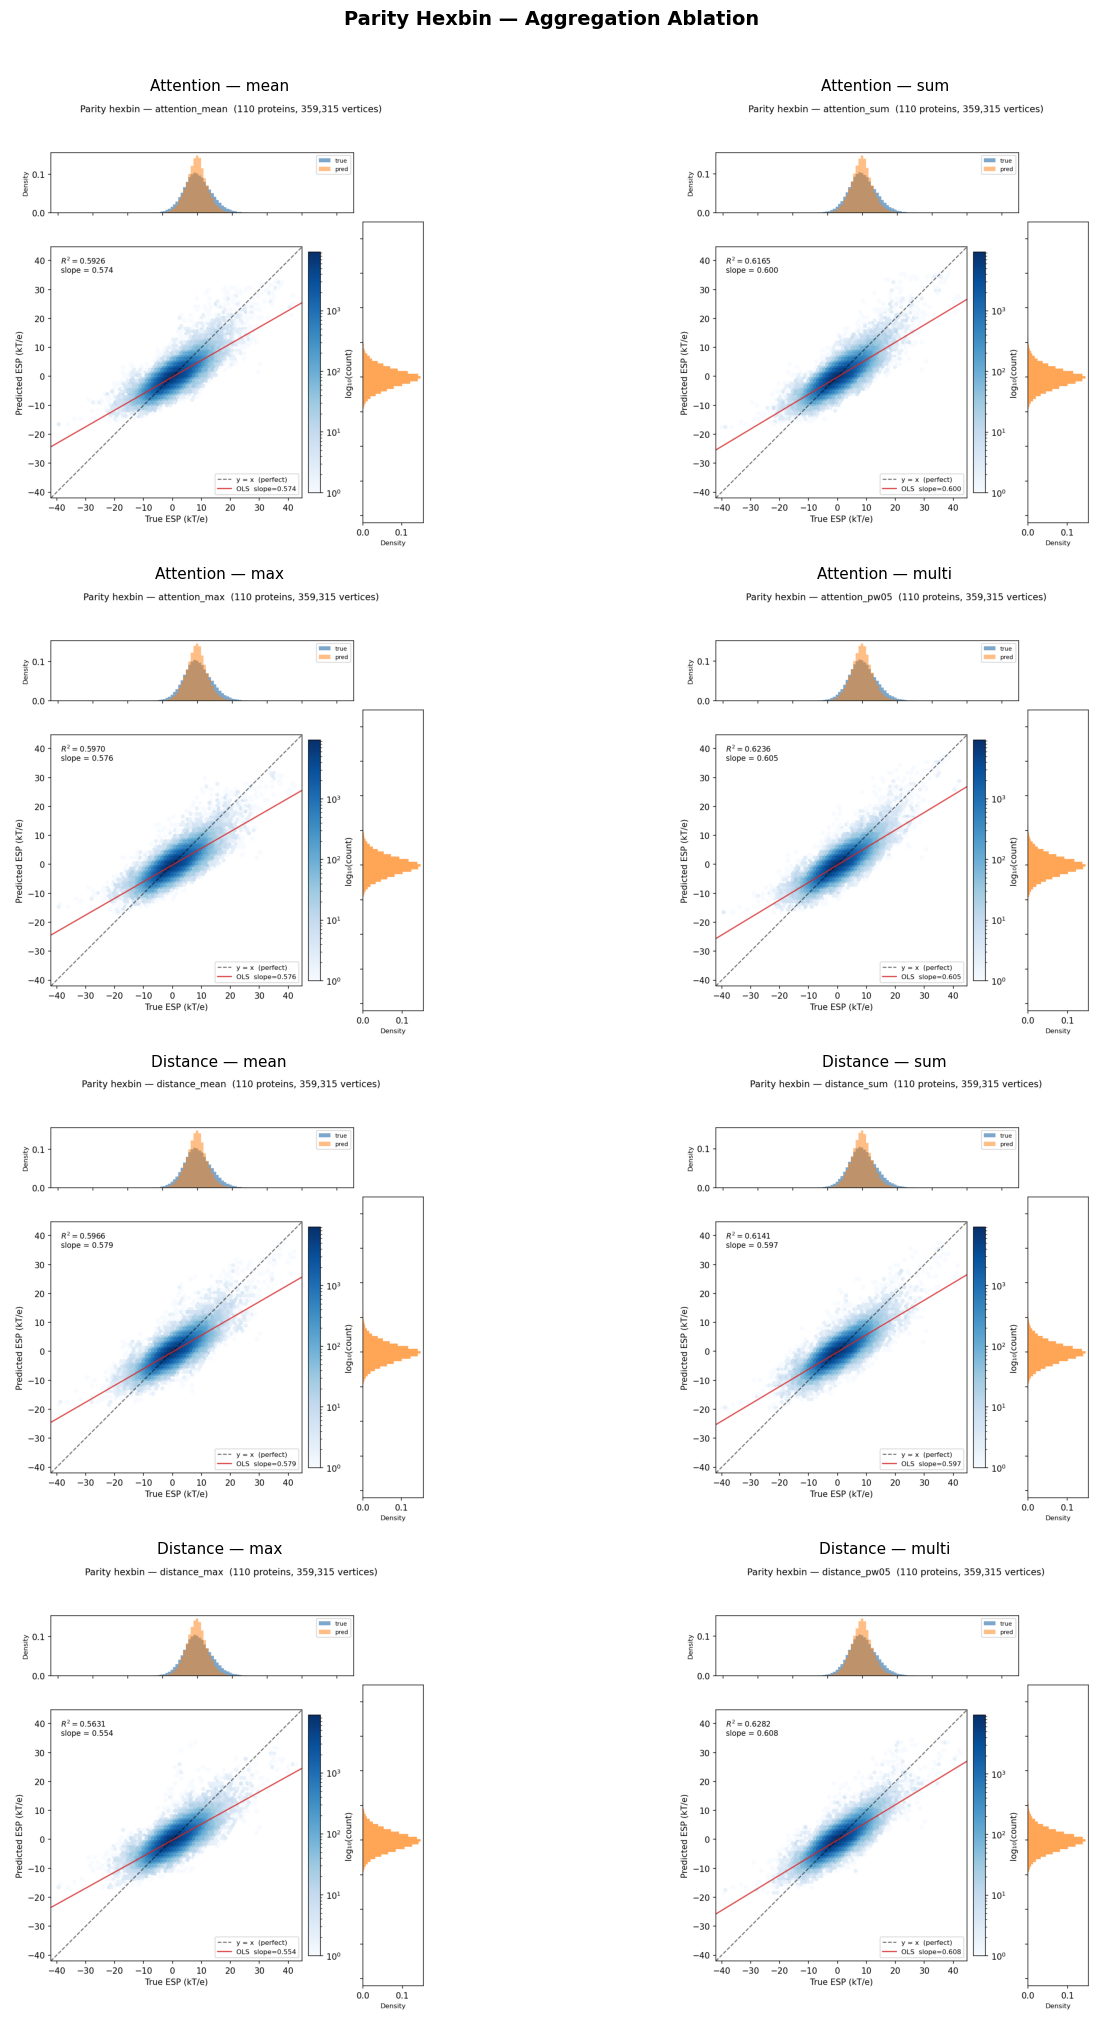

In [12]:
show_png_grid(RUNS, "parity_hexbin.png", "Parity Hexbin — Aggregation Ablation")

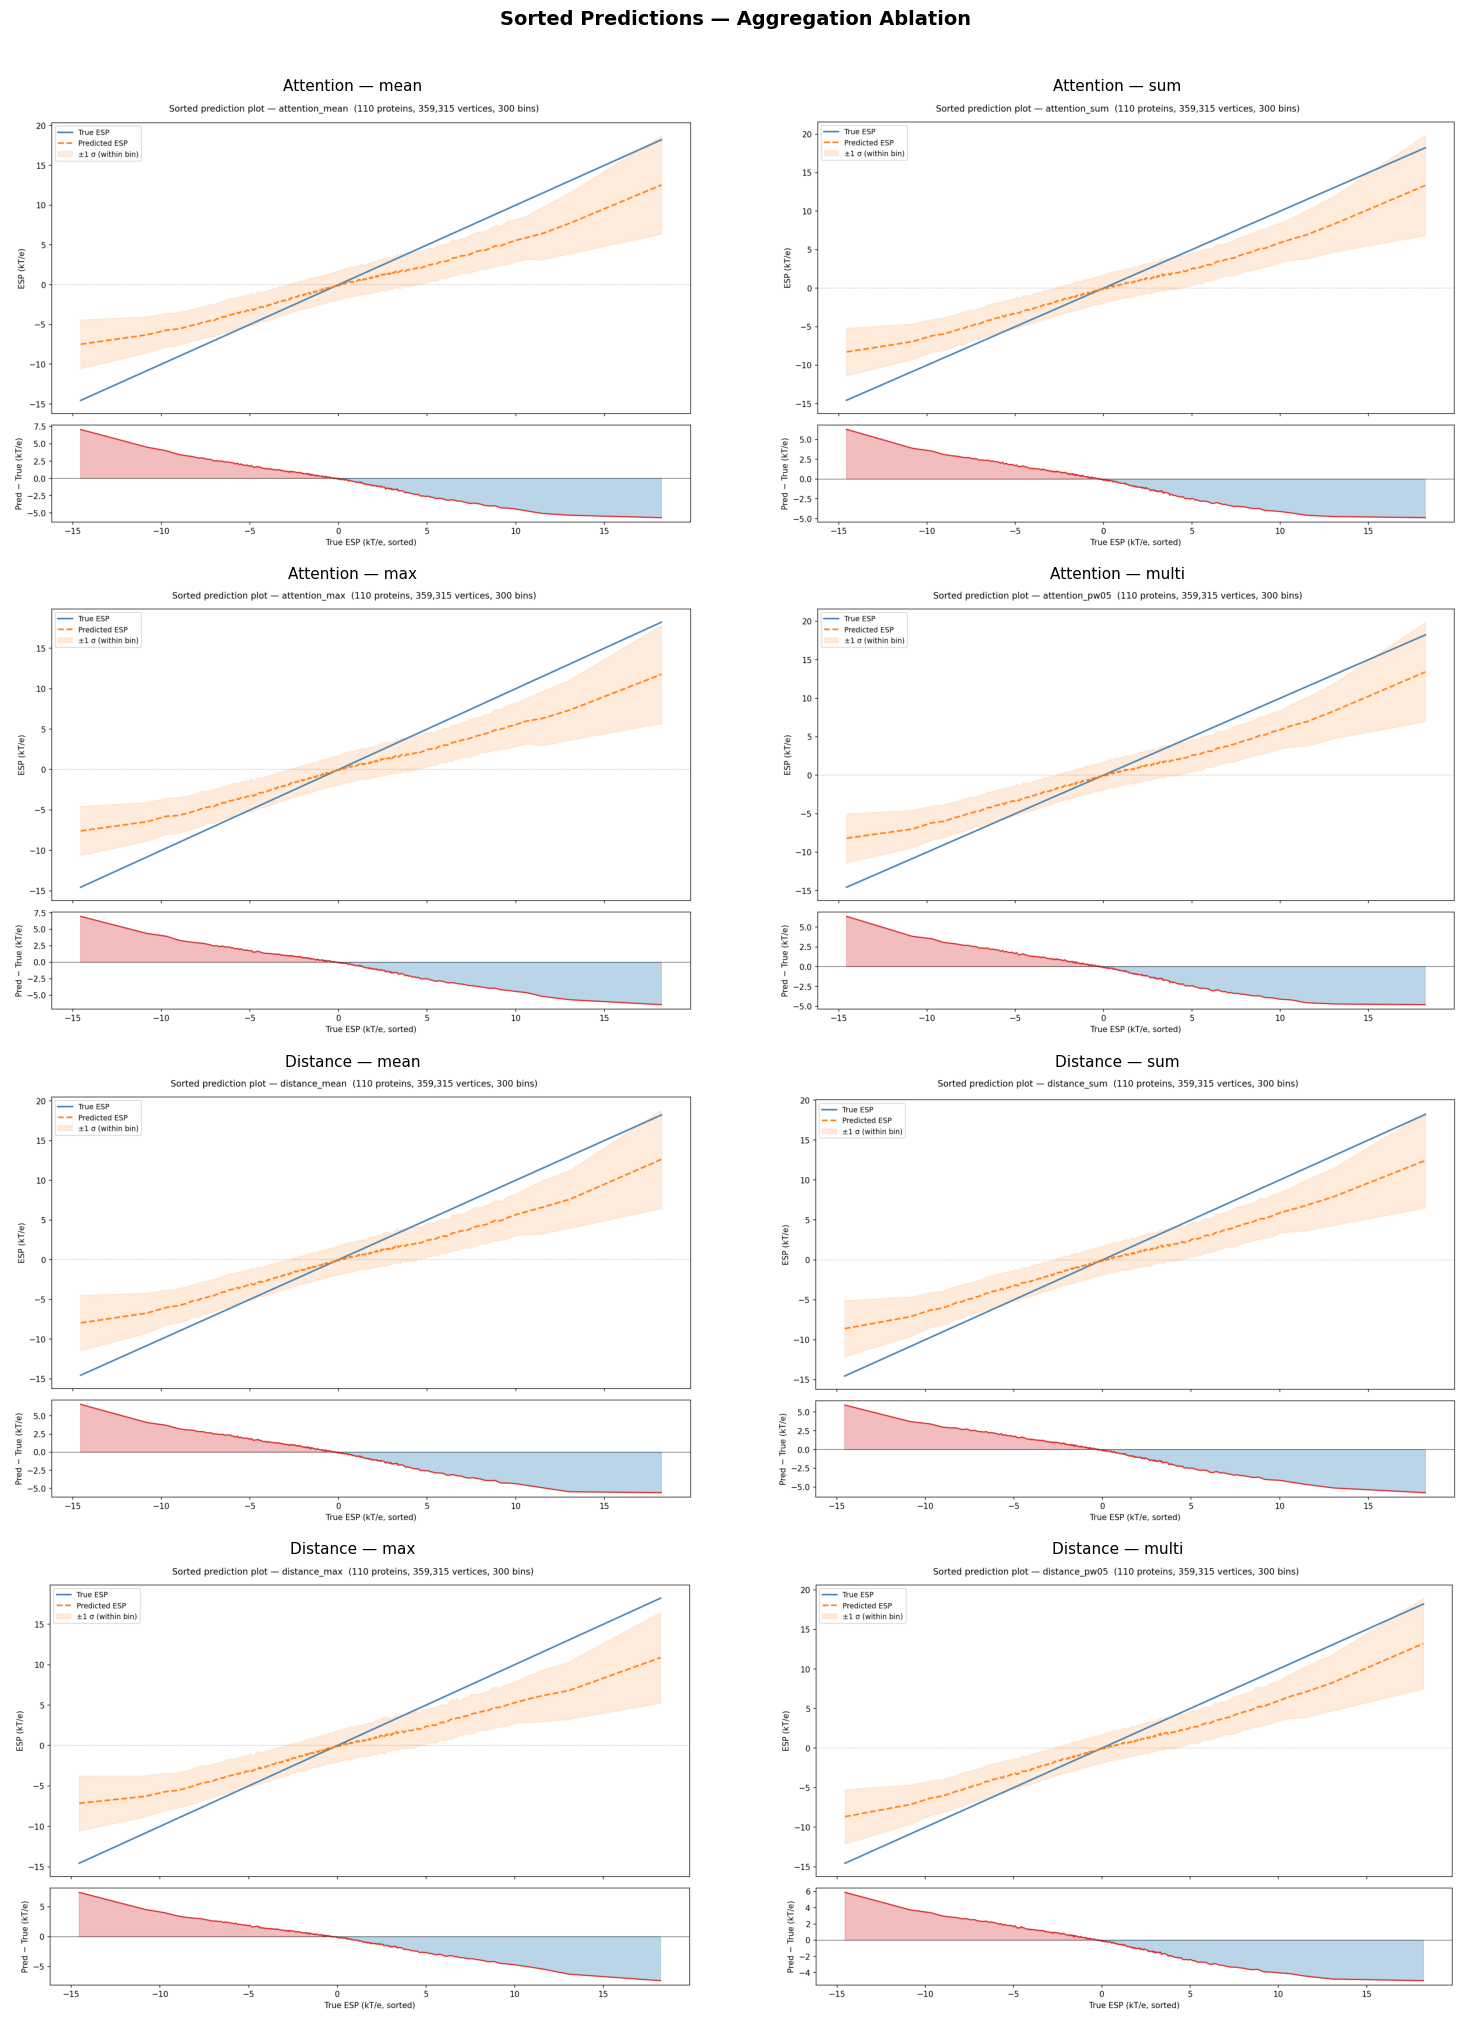

In [13]:
show_png_grid(RUNS, "sorted_predictions.png", "Sorted Predictions — Aggregation Ablation")

## 3. Training Curves

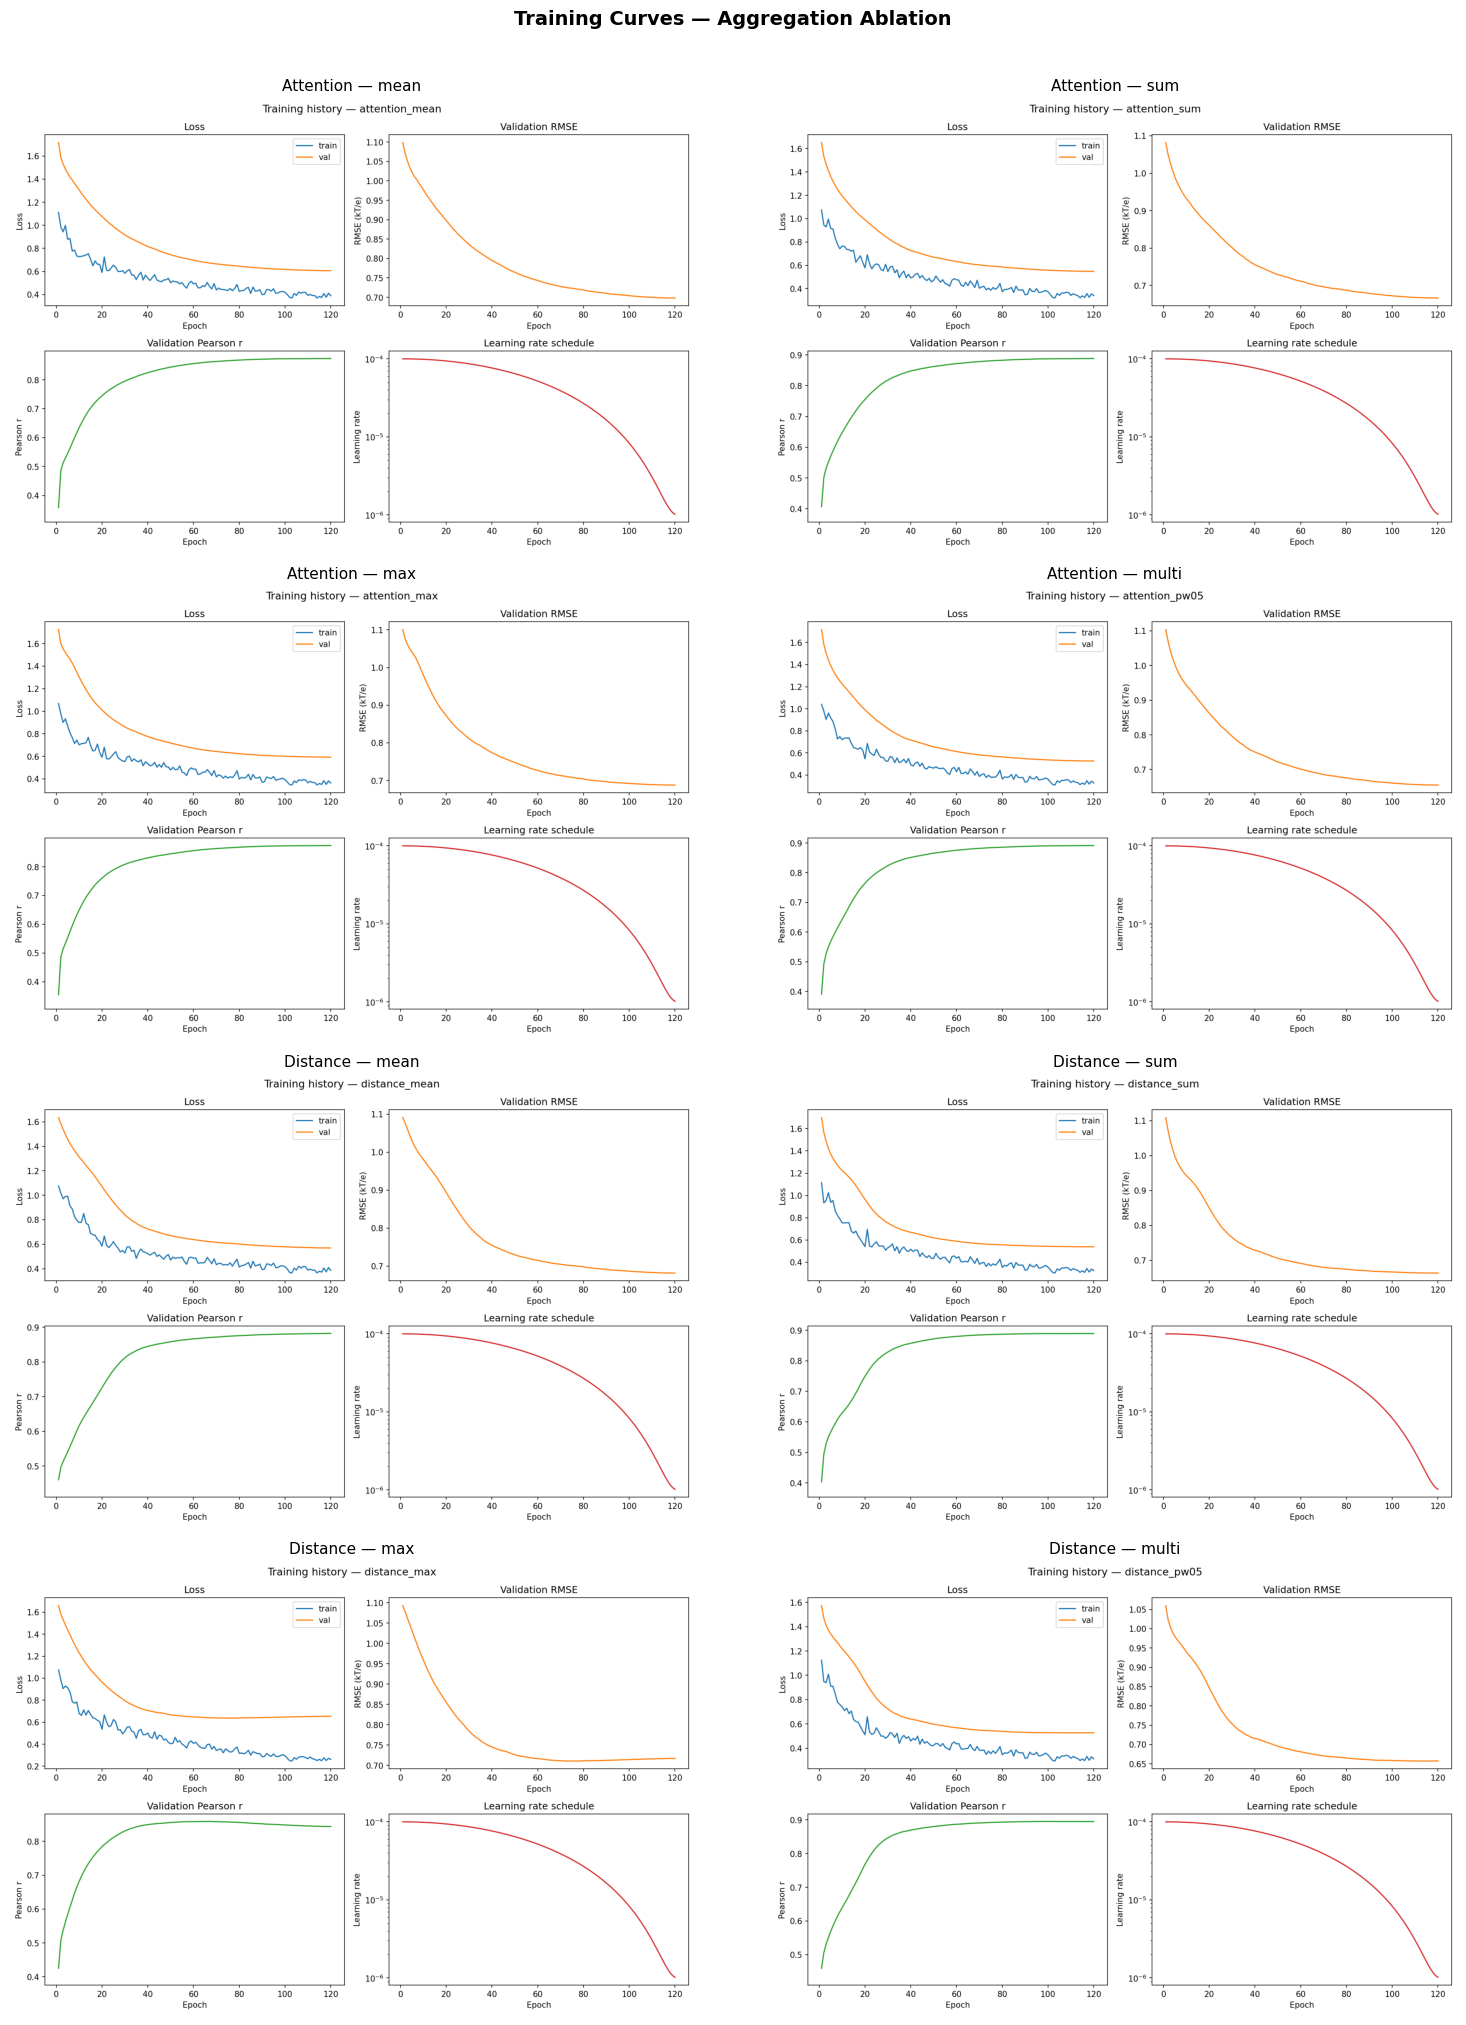

In [14]:
show_png_grid(RUNS, "training_curves.png", "Training Curves — Aggregation Ablation")

## 4. Validation Metrics Comparison (selection basis)

,Run,Model,Aggregation,Pearson r,RMSE,Val loss,Train loss,Train/val gap,Best epoch
3,Attention — multi,Attention,multi,0.8915,0.6551,0.5270,0.3283,-0.1987,120
1,Attention — sum,Attention,sum,0.8882,0.6666,0.5480,0.3408,-0.2073,120
2,Attention — max,Attention,max,0.8740,0.6879,0.5930,0.3641,-0.2290,120
0,Attention — mean,Attention,mean,0.8735,0.6981,0.6064,0.3896,-0.2168,120
7,Distance — multi,Distance,multi,0.8953,0.6573,0.5273,0.3179,-0.2093,110
5,Distance — sum,Distance,sum,0.8895,0.6633,0.5387,0.3254,-0.2134,120
4,Distance — mean,Distance,mean,0.8821,0.6813,0.5692,0.3856,-0.1836,120
6,Distance — max,Distance,max,0.8567,0.7108,0.6376,0.3330,-0.3046,77


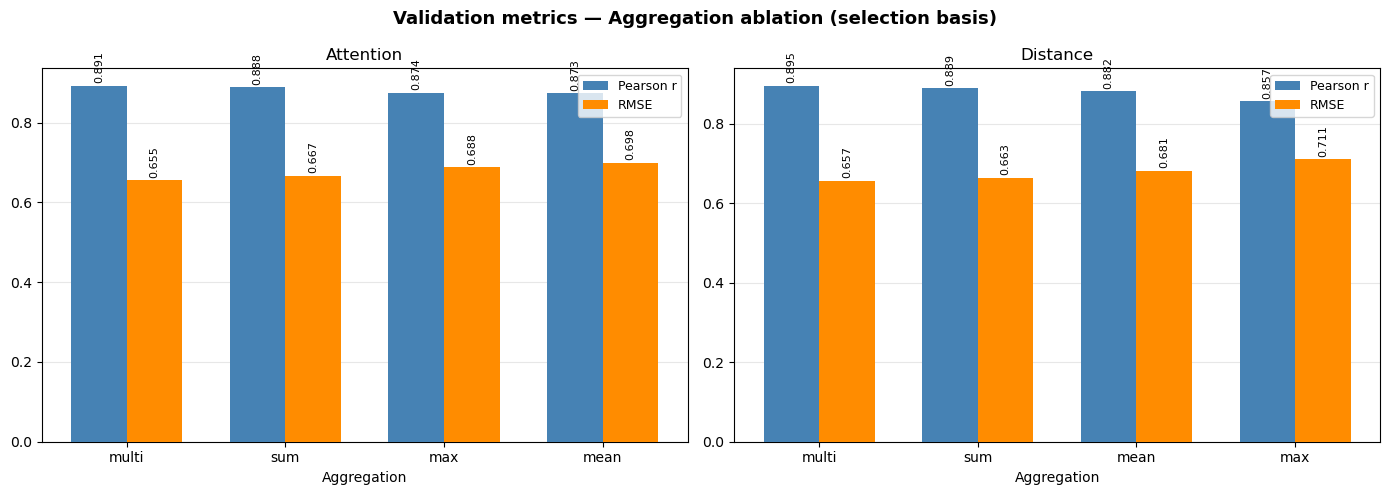

In [15]:
rows = []
for run in RUNS:
    csv_path = run["ckpt_dir"] / "metrics.csv"
    if not csv_path.exists():
        continue
    hist = pd.read_csv(csv_path)
    if hist.empty:
        continue
    best = hist.loc[hist["val_loss"].idxmin()]
    rows.append({
        "Run":          run["label"],
        "Model":        run["model_type"].capitalize(),
        "Aggregation":  run["agg"],
        "Pearson r":    best["val_pearson_r"],
        "RMSE":         best["val_rmse"],
        "Val loss":     best["val_loss"],
        "Train loss":   best["train_loss"],
        "Train/val gap": best["train_loss"] - best["val_loss"],
        "Best epoch":   int(best["epoch"]),
    })

val_df = pd.DataFrame(rows).sort_values(["Model", "Pearson r"], ascending=[True, False])
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
display(val_df)
plot_metric_bars(val_df, "Validation metrics — Aggregation ablation (selection basis)",
                  metrics=[("Pearson r", "steelblue"), ("RMSE", "darkorange")])

## 5. Test Metrics (reference only — not used for selection)

,Run,Model,Aggregation,Pearson r,RMSE,MAE,Train time (s),N proteins
3,Attention — multi,Attention,multi,0.8898,2.6598,2.0558,NaN,110
1,Attention — sum,Attention,sum,0.8898,2.6130,2.0184,4185.8000,110
0,Attention — mean,Attention,mean,0.8768,2.6931,2.0686,4659.1000,110
2,Attention — max,Attention,max,0.8754,2.6788,2.0526,4240.7000,110
7,Distance — multi,Distance,multi,0.8964,2.5730,1.9857,7082.3000,110
5,Distance — sum,Distance,sum,0.8892,2.6212,2.0193,4554.8000,110
4,Distance — mean,Distance,mean,0.8823,2.6800,2.0595,4609.2000,110
6,Distance — max,Distance,max,0.8596,2.7892,2.1345,4528.3000,110


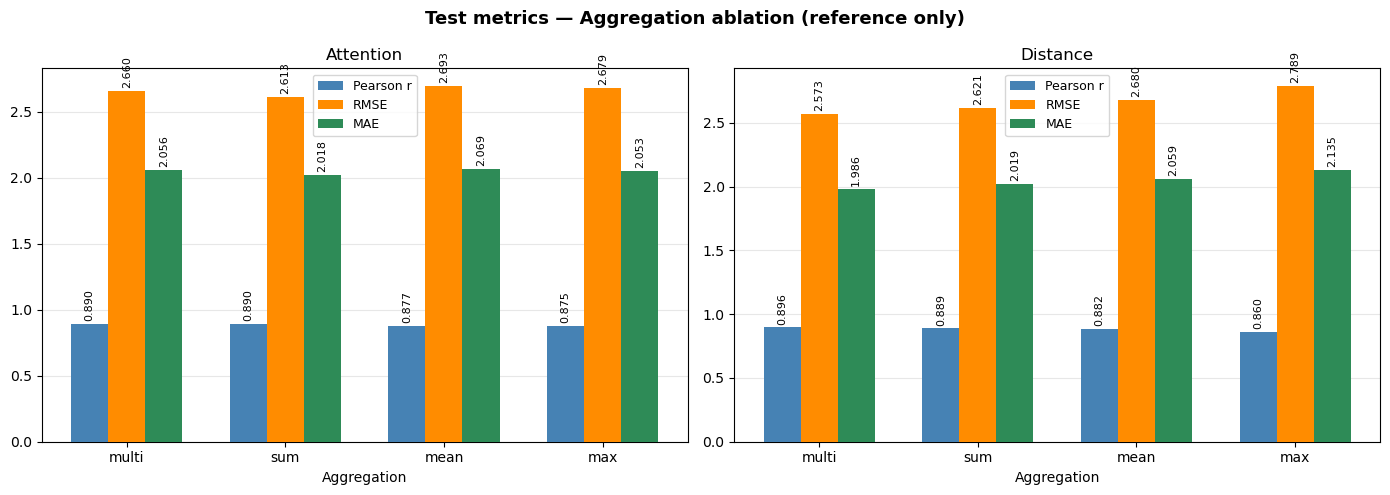

In [16]:
rows_test = []
for run in RUNS:
    metrics_path = run["ckpt_dir"] / "test_metrics.json"
    if not metrics_path.exists():
        continue
    with open(metrics_path) as f:
        data = json.load(f)
    g = data.get("global", {})
    rows_test.append({
        "Run":            run["label"],
        "Model":          run["model_type"].capitalize(),
        "Aggregation":    run["agg"],
        "Pearson r":      g.get("pearson_r"),
        "RMSE":           g.get("rmse"),
        "MAE":            g.get("mae"),
        "Train time (s)": g.get("train_wall_time_s"),
        "N proteins":     g.get("n_proteins"),
    })

test_df = pd.DataFrame(rows_test).sort_values(["Model", "Pearson r"], ascending=[True, False])
display(test_df)
plot_metric_bars(test_df, "Test metrics — Aggregation ablation (reference only)",
                  metrics=[("Pearson r", "steelblue"), ("RMSE", "darkorange"), ("MAE", "seagreen")])

## 6. Per-Protein Ranking

Per-protein Pearson r (from `test_metrics.json`) across all 8 runs — which
proteins are universally easy or hard, and which are aggregation-sensitive
(high rank variance across the 4 agg choices)?

In [17]:
pp_data: dict[str, dict[str, float]] = {}

for run in RUNS:
    metrics_path = run["ckpt_dir"] / "test_metrics.json"
    if not metrics_path.exists():
        continue
    with open(metrics_path) as f:
        data = json.load(f)
    pp = data.get("per_protein", {})
    pp_data[run["label"]] = {pid: v["pearson_r"] for pid, v in pp.items()}

all_proteins = sorted({pid for d in pp_data.values() for pid in d})
run_labels   = list(pp_data.keys())

pivot = pd.DataFrame(
    {label: [pp_data[label].get(pid, float("nan")) for pid in all_proteins]
     for label in run_labels},
    index=all_proteins,
)

def _short(pid):
    return pid.removeprefix("AF-").removesuffix("-F1")

pivot.index = [_short(p) for p in pivot.index]
pivot.columns = [
    label.replace("Attention — ", "Attn/").replace("Distance — ", "Dist/")
    for label in pivot.columns
]

pivot["_mean"] = pivot.mean(axis=1)
pivot = pivot.sort_values("_mean", ascending=False).drop(columns=["_mean"])

print(f"Loaded per-protein data for {len(pivot)} proteins across {len(run_labels)} runs.")

Loaded per-protein data for 110 proteins across 8 runs.


In [18]:
rank_df = pivot.rank(ascending=False, method="min").astype(int)

rank_df.insert(0, "Mean r",    pivot.mean(axis=1).round(4))
rank_df.insert(1, "Std r",     pivot.std(axis=1).round(4))
rank_df.insert(2, "Mean rank", rank_df.iloc[:, 2:].mean(axis=1).round(2))
rank_df.insert(3, "Rank std",  rank_df.iloc[:, 3:].std(axis=1).round(2))

rank_df = rank_df.sort_values("Mean rank")

print("Top 5 proteins (lowest mean rank = most consistently well-predicted):")
display(rank_df.head(5))

print("\nBottom 5 proteins (highest mean rank = most consistently difficult):")
display(rank_df.tail(5))

print("\nMost aggregation-sensitive proteins (highest rank std):")
display(rank_df.sort_values("Rank std", ascending=False).head(5))

Top 5 proteins (lowest mean rank = most consistently well-predicted):


,Mean r,Std r,Mean rank,Rank std,Attn/mean,Attn/sum,Attn/max,Attn/multi,Dist/mean,Dist/sum,Dist/max,Dist/multi
Q8RUD6,0.9513,0.0067,2.0000,1.2000,1,1,2,1,3,3,4,1
A1SHW4,0.9468,0.0100,4.1200,1.8100,5,5,6,5,2,2,6,2
Q9GKK3-3,0.9446,0.0095,4.2500,2.3800,3,3,3,2,8,4,8,3
Q8WXC6,0.9447,0.0131,5.7500,4.8600,2,7,5,15,1,1,10,5
Q8N100,0.9426,0.0063,6.3800,2.9700,6,9,4,6,12,7,3,4



Bottom 5 proteins (highest mean rank = most consistently difficult):


,Mean r,Std r,Mean rank,Rank std,Attn/mean,Attn/sum,Attn/max,Attn/multi,Dist/mean,Dist/sum,Dist/max,Dist/multi
P9WKL5,0.7738,0.0621,103.8800,10.9300,110,110,109,109,108,97,109,79
Q07395,0.7861,0.0299,105.3800,3.3400,103,98,107,107,107,106,107,108
P0A6Y5,0.7866,0.0335,105.5000,2.5100,108,106,110,104,104,105,102,105
G5E8Z2,0.7820,0.0158,106.2500,1.8300,105,109,104,108,106,107,104,107
A8WJR8,0.7618,0.0274,108.3800,1.3000,109,108,108,110,110,108,108,106



Most aggregation-sensitive proteins (highest rank std):


,Mean r,Std r,Mean rank,Rank std,Attn/mean,Attn/sum,Attn/max,Attn/multi,Dist/mean,Dist/sum,Dist/max,Dist/multi
A7I4I0,0.9009,0.0391,40.5000,29.2900,60,26,97,22,61,21,11,26
Q9ESL0,0.8661,0.0445,69.3800,23.4600,79,58,95,56,86,45,99,37
P55612,0.8885,0.0276,55.0000,23.3300,50,32,78,33,80,79,64,24
P96740,0.9271,0.0297,18.1200,22.9000,31,4,70,4,5,5,16,10
O13831,0.8671,0.0431,70.5000,19.1600,66,72,91,77,42,59,101,56


## 7. Decision

*Fill in from Section 4's validation table above.*

| Model | Winning aggregation | Val Pearson r | Val RMSE | Train/val gap | Runner-up |
|---|---|---|---|---|---|
| Attention | ? | ? | ? | ? | ? |
| Distance | ? | ? | ? | ? | ? |

`agg=multi` is the current config default carried into all later sweeps
(notebooks 09+); confirm here whether the `phase_b` re-run under the current
EMA + protein-weighted baseline still supports that choice.